#### IMPORTAR LIBRERIAS

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from gensim.models import KeyedVectors
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense, Concatenate
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import gensim.downloader as api
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc
)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import TruncatedSVD

#### LIMPIEZA DE LOS DATOS

In [ ]:
df_true = pd.read_csv('data/True.csv')
df_fake = pd.read_csv('data/Fake.csv')

df_true['output'] = 'True'
df_fake['output'] = 'Fake'
df_true['text'] = df_true['text'].str.replace(r'^[^–\-]+[–\-]\s*', '', regex=True).str.lstrip()
df_true['title'] = df_true['title'].str.lstrip()
df_fake['title'] = df_fake['title'].str.lstrip()
df_fake['text'] = df_fake['text'].str.lstrip()

In [15]:
data = pd.concat([df_true, df_fake], ignore_index=True)
data.drop_duplicates()
data.head()

,title,text,subject,date,output
0,"As U.S. budget fight looms, Republicans flip t...",The head of a conservative Republican faction ...,politicsNews,"December 31, 2017",True
1,U.S. military to accept transgender recruits o...,Transgender people will be allowed for the fir...,politicsNews,"December 29, 2017",True
2,Senior U.S. Republican senator: 'Let Mr. Muell...,The special counsel investigation of links bet...,politicsNews,"December 31, 2017",True
3,FBI Russia probe helped by Australian diplomat...,Trump campaign adviser George Papadopoulos tol...,politicsNews,"December 30, 2017",True
4,Trump wants Postal Service to charge 'much mor...,President Donald Trump called on the U.S. Post...,politicsNews,"December 29, 2017",True


In [18]:
data['output'].value_counts()
data['output'].value_counts(normalize=True) * 100 #porcentaje

output
Fake    52.298543
True    47.701457
Name: proportion, dtype: float64

#### VECTORIZAR

In [20]:
# Extraer variables
X1 = data['title'].astype(str)
X2 = data['text'].astype(str)
y = np.array(data['output'])

In [22]:
# Tokenizer
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X1 + " " + X2)

# Secuencias numéricas
sequences1 = tokenizer.texts_to_sequences(X1)
sequences2 = tokenizer.texts_to_sequences(X2)

# Padding
max_len = 5000
X1_padded = pad_sequences(sequences1, maxlen=max_len)
X2_padded = pad_sequences(sequences2, maxlen=max_len)

In [23]:
# Dividir
X1_train, X1_val, X2_train, X2_val, y_train, y_val = train_test_split(
    X1_padded, X2_padded, y, test_size=0.25, random_state=42)

# Convertir y a binario
y_train = np.where(y_train == "Fake", 0, 1).astype(np.float32)
y_val = np.where(y_val == "Fake", 0, 1).astype(np.float32)

In [24]:
# Carga automática del modelo preentrenado desde gensim
w2v_model = api.load("word2vec-google-news-300")

[=-------------------------------------------------] 3.3% 54.4/1662.8MB downloaded


KeyboardInterrupt



In [ ]:
# Crear embedding matrix
embedding_dim = 300
vocab_size = len(tokenizer.word_index) + 1
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in tokenizer.word_index.items():
    if word in w2v_model:
        embedding_matrix[i] = w2v_model[word]
    else:
        embedding_matrix[i] = np.random.normal(0, 0.1, embedding_dim)

# Capa embedding con pesos preentrenados
from tensorflow.keras.layers import Embedding
embedding_layer = Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    trainable=False)

#### ENTRENAR MODELO

In [ ]:
# Concatenar X1 y X2 horizontalmente para crear un único conjunto de entrada
X_train_combined = np.hstack((X1_train, X2_train))
X_val_combined = np.hstack((X1_val, X2_val))

C:\Users\marta\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(C=1, max_iter=500, random_state=42)

In [ ]:
svd = TruncatedSVD(n_components=500)  # 500 dimensiones
X_train_combined_reduced = svd.fit_transform(X_train_combined)
X_val_combined_reduced = svd.transform(X_val_combined)

# Buscar mejores hiperparámetros
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'class_weight': [None, 'balanced'],
    'solver': ['liblinear']  # bueno para conjuntos pequeños
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    cv=3,  # Usar 3 pliegues 
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)


grid.fit(X_train_combined_reduced, y_train)

# Mejor modelo
best_lr = grid.best_estimator_
print(f"Mejor modelo: {best_lr}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
🔍 Mejor modelo: LogisticRegression(C=0.1, max_iter=1000, random_state=42, solver='liblinear')


In [76]:
# Entrenar el modelo
lr = LogisticRegression(penalty='l2', max_iter=1000, C=0.01, random_state=42)
lr.fit(X_train_combined, y_train)

C:\Users\marta\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(C=0.01, max_iter=1000, random_state=42)

*Métricas de validación*

In [77]:
# Predicciones
y_train_pred = lr.predict(X_train_combined)
y_val_pred = lr.predict(X_val_combined)

# Accuracy
train_acc = accuracy_score(y_train, y_train_pred)
val_acc = accuracy_score(y_val, y_val_pred)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")

Train Accuracy: 0.7905
Validation Accuracy: 0.7601


A partir de estas métricas de accuracy, podemos pensar que no es un modelo que haga una predicción muy exacta, ya que en ambos casos tenemos un valor menor de 80.

Es lógico obtener estos resultados ya que la regresión lineal es un modelo muy simple y que no se ajusta a las necesidades de nuestro estudio.

In [78]:
# Predicciones
y_pred = lr.predict(X_val_combined)

# Métricas
acc = accuracy_score(y_val, y_pred)
prec = precision_score(y_val, y_pred)
rec = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
cm = confusion_matrix(y_val, y_pred)

# Imprimir resultados
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")
print("\nConfusion Matrix:")
print(cm)

# Reporte de clasificación detallado (opcional)
print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=["Fake", "Real"]))

Accuracy:  0.7601
Precision: 0.7334
Recall:    0.7871
F1 Score:  0.7593

Confusion Matrix:
[[4285 1544]
 [1149 4247]]

Classification Report:
              precision    recall  f1-score   support

        Fake       0.79      0.74      0.76      5829
        Real       0.73      0.79      0.76      5396

    accuracy                           0.76     11225
   macro avg       0.76      0.76      0.76     11225
weighted avg       0.76      0.76      0.76     11225



#### VISUALIZAR RESULTADOS

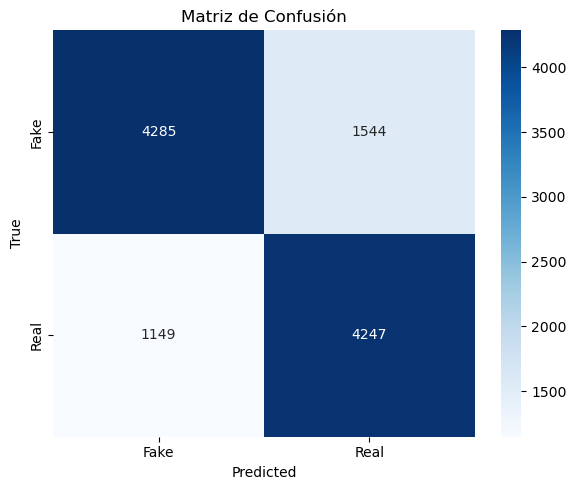

<Figure size 600x500 with 0 Axes>

In [79]:
# Matriz de confusión (gráfica)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"])
plt.title("Matriz de Confusión")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.show()

La matriz de confusión es una herramienta que permite evaluar el rendimiento de un modelo al mostrar el número de verdaderos positivos (en este caso reales), verdaderos negativos (en este caso fake), falsos positivos y falsos negativos. 

Un análisis de esta matriz puede revelar si el modelo tiene problemas específicos, como un alto número de falsos positivos (predicciones incorrectas de la clase positiva) o falsos negativos (fallos al identificar la clase positiva), lo que puede indicar un sesgo hacia una clase o dificultades para distinguir entre clases. 

En este caso, la mayoría de registros están bien clasificados, aunque encontramos que 1544 del total se predicen como reales cuando son fake, y 1149 se predicen como fake y son reales, los cuales son números bastante elevados.


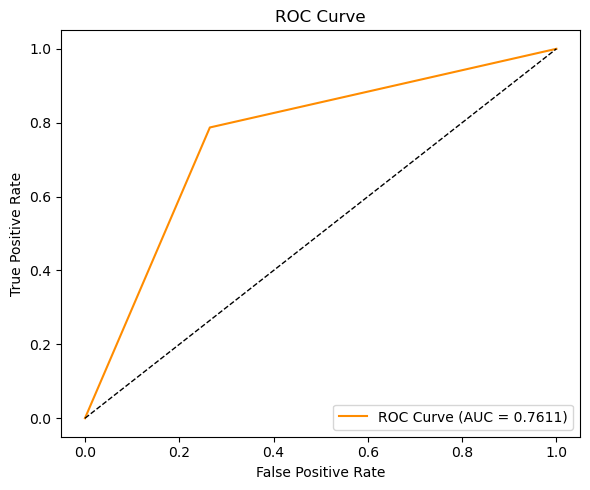

In [80]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_val, y_val_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})", color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

La Curva ROC (Receiver Operating Characteristic) es una representación gráfica que evalúa el rendimiento de un modelo clasificatorio al mostrar la relación entre la tasa de verdaderos positivos (True Positive Rate, TPR) y la tasa de falsos positivos (False Positive Rate, FPR) para diferentes umbrales de decisión.

Lo ideal sería que estuviese lo más alejado de la diagonal, con un valor de AUC lo más cercano a 1 posible. En este caso AUC= 0.7611, luego nos reafirmamos que no es una clasificación muy exacta.